In [ ]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.7 MB/s eta 0:00:00



Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 75.5ms
Speed: 13.5ms preprocess, 75.5ms inference, 45.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict4


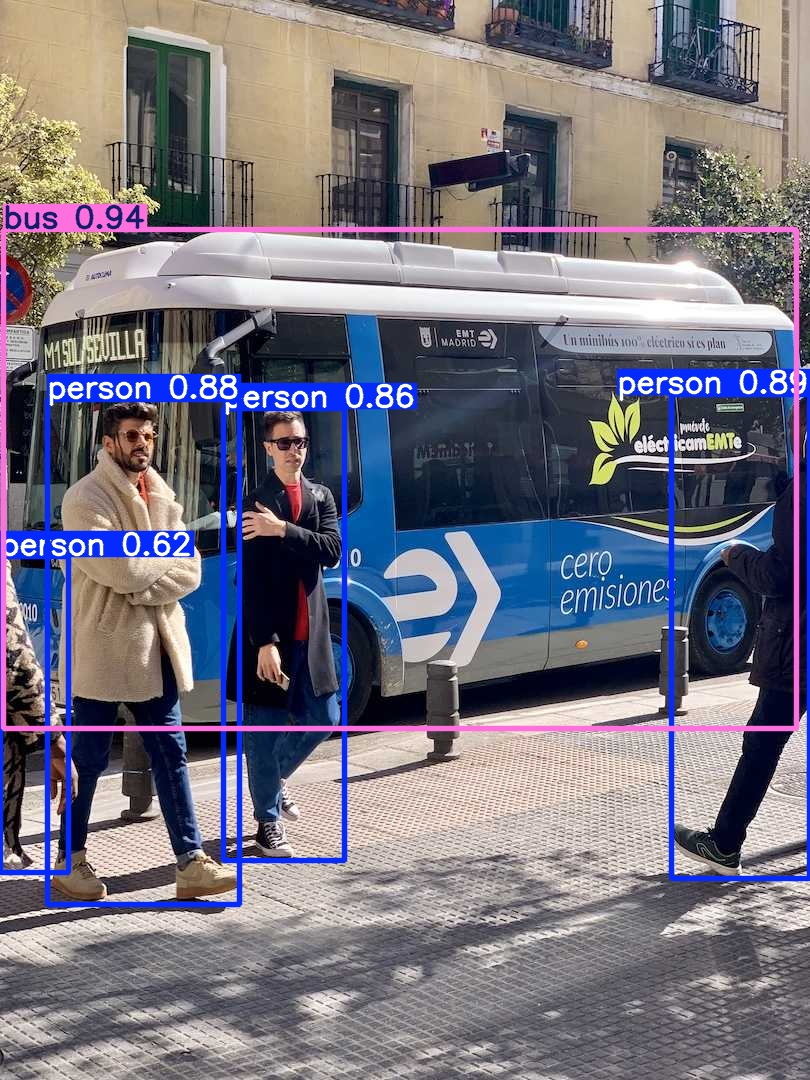

In [ ]:
from ultralytics import YOLO
model = YOLO('yolo11n.pt')
results = model.predict('https://ultralytics.com/images/bus.jpg', save=True)

# Hiển thị kết quả để ăn mừng!
import cv2
from google.colab.patches import cv2_imshow
res_img = cv2.imread('runs/detect/predict/bus.jpg')
cv2_imshow(res_img)

Train for new dataset

In [ ]:
!gdown "1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R"

Downloading...
From (original): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R
From (redirected): https://drive.google.com/uc?id=1twdtZEfcw4ghSZIiPDypJurZnNXzMO7R&confirm=t&uuid=3553135e-89ea-4f9b-b0df-930ed85fb9a6
To: /content/Safety_Helmet_Dataset.zip
100% 33.7M/33.7M [00:00<00:00, 92.2MB/s]


In [ ]:
!mkdir dataset

In [ ]:
!unzip -q "/content/Safety_Helmet_Dataset.zip" -d "/content/dataset"

In [ ]:
model_path = "/content/yolo11n.pt"
model = YOLO(model_path)

In [ ]:
yaml_path = "/content/dataset/data.yaml"
epoches =20
img_size =640
batch_size = 32
model.train(data=yaml_path, epochs=epoches, imgsz=img_size, batch=batch_size)

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ddd480adbe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
!find /content/runs -name "best.pt"

/content/runs/detect/train6/weights/best.pt
/content/runs/detect/train5/weights/best.pt


In [ ]:
trained_path = "/content/runs/detect/train6/weights/best.pt"
model = YOLO(trained_path)
model.val(data = yaml_path,imgsz=640,split='test')

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 18.1±7.2 MB/s, size: 28.8 KB)
val: Scanning /content/dataset/test/labels... 109 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 109/109 1.0Kit/s 0.1s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3it/s 3.0s
                   all        109        320      0.807      0.887      0.904      0.466
                  head         12         16      0.908      0.938      0.973      0.443
                helmet         98        162      0.809      0.914      0.945      0.492
                person         78        142      0.705      0.809      0.794      0.463
Speed: 6.6ms preprocess, 6.2ms inference, 0.0ms loss, 2.2ms postprocess per image
Results 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ddd480b5520>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04